In [1]:
ra_parameter = 0
sign_parameter = 0

In [2]:
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
from spectral_cube import SpectralCube as sc
from tqdm.notebook import tqdm,trange

from pybaselines import Baseline
from pybaselines.utils import gaussian, relative_difference
from pybaselines._banded_utils import PenalizedSystem
from pybaselines._weighting import _arpls

import os
import tempfile
from concurrent.futures import ProcessPoolExecutor

from rotation_model_numpy import calc_v_dev
from astropy.coordinates import SkyCoord

# disable the Parameter Warning
import warnings
from pybaselines.utils import ParameterWarning
warnings.filterwarnings("ignore", category=ParameterWarning)


%matplotlib widget

In [3]:
# Define the source and target cube patterns

crafts_pattern = "./South/Combined/CRAFTS_RA{ra}_DEC-13_2.fits"

# Define RA ranges and signs

ra_ranges = ["60_80", "80_100", "100_120", "120_140"]

ra = ra_ranges[ra_parameter]

crafts_file = crafts_pattern.format(ra=ra)

In [4]:
cube = sc.read(crafts_file, memmap=True).with_spectral_unit(u.km / u.s)
data = cube.unmasked_data[:, :, :].value
data = np.nan_to_num(data)
n_v, n_y, n_x = data.shape

In [5]:
def pix_to_galactic_l_b(celestial_wcs, xpix, ypix):
    lonlat = celestial_wcs.all_pix2world(xpix, ypix, 0)
    ctypes = celestial_wcs.wcs.ctype
    c0 = ctypes[0].upper()
    if "RA" in c0 or "DEC" in c0:
        sc = SkyCoord(ra=lonlat[0] * u.deg, dec=lonlat[1] * u.deg, frame="fk5")
        gal = sc.galactic
        return gal.l.deg, gal.b.deg
    else:
        return lonlat[0], lonlat[1]

In [6]:
def masked_arpls(y, mask=None, lam=1e8, diff_order=2, tol=1e-3, max_iter=50, weights=None):
    """A mask-aware version of the arpls algorithm."""
    len_y = len(y)
    if mask is None:
        mask = np.ones(len_y, dtype=bool)
        y_fit = y
    else:
        y_fit = 1 * y  # don't want to override the input y, so make a copy
        y_fit[~mask] = 0  # cover that case of nan values in y since 0 * nan = nan rather than 0
    if weights is None:
        weights = np.ones(len_y)
    else:
        weights = 1 * weights  # don't want to override the input weights, so make a copy
    weights[~mask] = 0
    whittaker_system = PenalizedSystem(len(y), lam=lam, diff_order=diff_order)
    for _ in range(max_iter):
        baseline = whittaker_system.solve(
            whittaker_system.add_diagonal(weights), weights * y_fit,
        )
        # need to ignore the problem regions in y since they would otherwise affect
        # the arpls weighting; could alternatively do:
        # _arpls(np.interp(x, x[mask], y[mask]), baseline) to approximate
        # the y-values, but it leads to a slightly different result
        calc_weights, exit_early = _arpls(y[mask], baseline[mask])
        if exit_early:
            break
        new_weights = np.zeros(len_y)
        new_weights[mask] = calc_weights
        if relative_difference(weights, new_weights) < tol:
            break
        weights = new_weights
    return baseline

In [7]:
wcs = cube.wcs
ny, nx = data.shape[-2], data.shape[-1]
vel_axis = cube.spectral_axis.value
nv = len(vel_axis)

i_grid, j_grid = np.meshgrid(np.arange(nx), np.arange(ny), indexing='ij')

l_deg, b_deg = pix_to_galactic_l_b(wcs.celestial, i_grid, j_grid)

v_max, v_min = calc_v_dev(l_deg, b_deg, model="poly", v_dev=30)

vmax_map = v_max.T
vmin_map = v_min.T

pos_mask = vel_axis[:, None, None] > vmax_map[None, :, :]
neg_mask = vel_axis[:, None, None] < vmin_map[None, :, :]

# 这是 v_dev > 30 区域
highv_mask = pos_mask | neg_mask
baseline_mask = highv_mask

In [8]:
from joblib import Parallel, delayed
import numpy as np

n_v, n_y, n_x = data.shape

# ----------------------------
# 1️⃣ 拉平数据
# ----------------------------\

In [ ]:
import numpy as np
from joblib import Parallel, delayed

n_v, n_y, n_x = data.shape
n_spec = n_y * n_x

def process_index(i):
    iy = i // n_x
    ix = i % n_x

    spectrum = data[:, iy, ix]
    mask_1d = baseline_mask[:, iy, ix]

    baseline = masked_arpls(
        spectrum,
        mask=mask_1d,
        lam=3e8,
        diff_order=2,
        tol=1e-3,
        max_iter=50
    )

    return i, spectrum - baseline


results = Parallel(
    n_jobs=-1,
    backend="loky",
    batch_size=200,     # 非常重要
    verbose=5
)(
    delayed(process_index)(i) for i in range(n_spec)
)

# 写回结果
data_corrected = np.zeros_like(data)

for i, corrected in results:
    iy = i // n_x
    ix = i % n_x
    data_corrected[:, iy, ix] = corrected

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done 4848 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done 22848 tasks      | elapsed:    7.7s
[Parallel(n_jobs=-1)]: Done 48048 tasks      | elapsed:   12.0s
[Parallel(n_jobs=-1)]: Done 80448 tasks      | elapsed:   17.4s
[Parallel(n_jobs=-1)]: Done 120048 tasks      | elapsed:   23.2s
[Parallel(n_jobs=-1)]: Done 166848 tasks      | elapsed:   30.9s
[Parallel(n_jobs=-1)]: Done 220848 tasks      | elapsed:   41.2s
[Parallel(n_jobs=-1)]: Done 282048 tasks      | elapsed:   51.3s
[Parallel(n_jobs=-1)]: Done 350448 tasks      | elapsed:  1.1min


In [ ]:
pos_cube = sc(data=np.where(pos_mask, data_corrected, 0)*cube.unit, wcs=cube.wcs)
neg_cube = sc(data=np.where(neg_mask, data_corrected, 0)*cube.unit, wcs=cube.wcs)

vmax_global = np.min(vmax_map)
max_v = np.max(vel_axis)

min_v = np.min(vel_axis)
vmin_global = np.max(vmin_map)

pos_cube_slab = pos_cube.spectral_slab(vmax_global * u.km/u.s, max_v * u.km/u.s)
neg_cube_slab = neg_cube.spectral_slab(min_v * u.km/u.s, vmin_global * u.km/u.s)

In [ ]:
def displayimage(cube, region=None):
    img = cube.moment(order=0).value  # moment 0
    fig, ax = plt.subplots(
        figsize=(5, 3),
        layout="compressed",
        subplot_kw={"projection": cube.wcs.celestial},
    )
    norm = simple_norm(np.array(img), min_percent=5, max_percent=95, stretch="linear")
    im = ax.imshow(img, norm=norm, cmap="viridis", origin="lower")
    lon = ax.coords[0]
    lat = ax.coords[1]
    lon.set_major_formatter("dd")
    lat.set_major_formatter("dd")
    lon.set_axislabel("RA")
    lat.set_axislabel("Dec")
    if region != None:
        region.plot(color="white")
    plt.colorbar(im)
    plt.show()

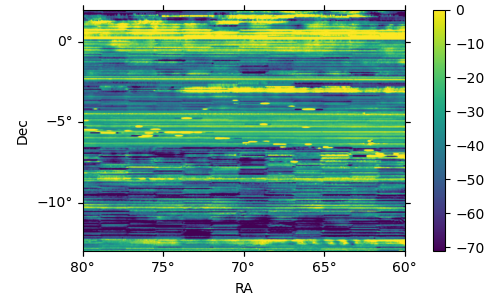

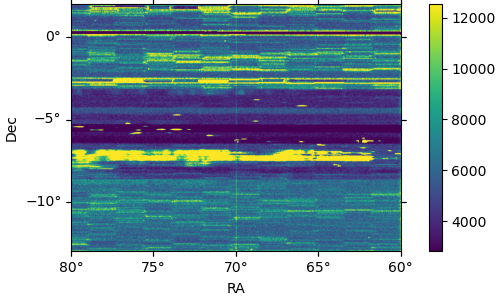

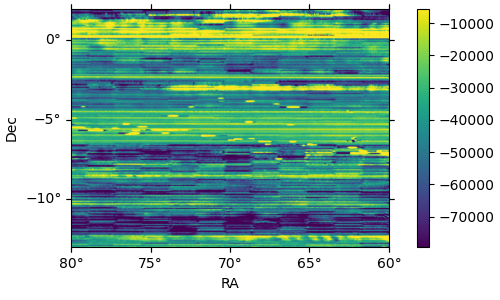

In [ ]:
displayimage(cube)
displayimage(pos_cube_slab)
displayimage(neg_cube_slab)

In [ ]:
# Save the corrected cube to a new FITS file
corrected_cube.write(corrected_file, overwrite=True)